In [ ]:
import os, gc
import numpy as np
import pandas as pd
import psutil

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer


def mem_gb():
    return psutil.Process(os.getpid()).memory_info().rss / 1024**3

# Bayesian logistic regression
import pymc as pm
import arviz as az


### Bayesian logistic baseline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/My Drive/Colab Datasets/BML/lendingclub_sample_50k.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd


df_bayes = df.copy()

df_bayes = df_bayes.replace(999, np.nan)

TARGET_COL = "loan_status_binary"

drop_cols = [

# payment leakage
"out_prncp",
"out_prncp_inv",
"total_pymnt",
"total_pymnt_inv",
"total_rec_prncp",
"total_rec_int",
"total_rec_late_fee",
"recoveries",
"collection_recovery_fee",
"last_pymnt_amnt",

# indirect leakage
"collections_12_mths_ex_med",
"mths_since_last_major_derog",
"policy_code",
 "grade",
 "sub_grade",

# high cardinality / messy
"zip_code",
"addr_state",
"earliest_cr_line"

]

df_bayes = df_bayes.drop(columns=[c for c in drop_cols if c in df_bayes.columns], errors="ignore")
df_bayes = df_bayes.dropna(subset=[TARGET_COL])

num_keep = [
    "loan_amnt","int_rate","installment","annual_inc","dti","delinq_2yrs",
    "inq_last_6mths","open_acc","pub_rec","revol_bal","revol_util",
    "total_acc","acc_now_delinq","tot_cur_bal","bc_util","mort_acc",
    "num_actv_bc_tl","num_actv_rev_tl","num_bc_sats","num_rev_tl_bal_gt_0",
    "num_sats","pct_tl_nvr_dlq","percent_bc_gt_75","pub_rec_bankruptcies",
    "tax_liens","tot_hi_cred_lim","total_bal_ex_mort","total_bc_limit"
]

cat_keep = [
    "term","emp_length","home_ownership",
    "verification_status","purpose","initial_list_status",
    "application_type","disbursement_method","has_delinq"
]

use_cols = [c for c in num_keep + cat_keep + [TARGET_COL] if c in df_bayes.columns]
df_bayes = df_bayes[use_cols].copy()

print(df_bayes.shape)
print(df_bayes[TARGET_COL].value_counts(normalize=True))

(50000, 38)
loan_status_binary
0    0.86958
1    0.13042
Name: proportion, dtype: float64


In [ ]:
df_bayes.head()

,loan_amnt,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,...,term,emp_length,home_ownership,verification_status,purpose,initial_list_status,application_type,disbursement_method,has_delinq,loan_status_binary
0,30000,9.99,967.88,120000.0,17.46,0.0,1.0,9.0,0.0,30047.0,...,36 months,10+ years,RENT,Source Verified,credit_card,f,Individual,Cash,0,0
1,10000,14.08,342.17,90000.0,8.69,3.0,0.0,5.0,0.0,8547.0,...,36 months,5 years,RENT,Not Verified,debt_consolidation,w,Individual,Cash,1,0
2,16000,16.91,396.87,145000.0,13.57,0.0,2.0,14.0,0.0,28012.0,...,60 months,< 1 year,MORTGAGE,Source Verified,credit_card,w,Individual,Cash,0,0
3,20000,10.49,649.96,150000.0,7.72,0.0,0.0,5.0,0.0,13332.0,...,36 months,10+ years,RENT,Verified,debt_consolidation,f,Individual,Cash,1,0
4,4500,7.97,140.96,56000.0,14.23,0.0,1.0,5.0,0.0,7738.0,...,36 months,< 1 year,RENT,Not Verified,credit_card,w,Individual,Cash,0,0


In [ ]:

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X = df_bayes.drop(columns=[TARGET_COL])
y = df_bayes[TARGET_COL].astype(int)

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

num_cols = [c for c in num_keep if c in X_train_b.columns]
cat_cols = [c for c in cat_keep if c in X_train_b.columns]

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=0.01, sparse_output=False))
])

pre_bayes = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

Xtr_b_full = pre_bayes.fit_transform(X_train_b).astype(np.float32)
Xte_b_full = pre_bayes.transform(X_test_b).astype(np.float32)

ytr_b_full = np.asarray(y_train_b).astype(np.int32)
yte_b = np.asarray(y_test_b).astype(np.int32)

print("Train matrix:", Xtr_b_full.shape)
print("Test matrix:", Xte_b_full.shape)

Train matrix: (40000, 63)
Test matrix: (10000, 63)


In [ ]:
MAX_ROWS = 12000

if Xtr_b_full.shape[0] > MAX_ROWS:
    idx_sub, _ = train_test_split(
        np.arange(Xtr_b_full.shape[0]),
        train_size=MAX_ROWS,
        stratify=ytr_b_full,
        random_state=42
    )
    Xtr_b_sub = Xtr_b_full[idx_sub]
    ytr_b_sub = ytr_b_full[idx_sub]
else:
    Xtr_b_sub = Xtr_b_full
    ytr_b_sub = ytr_b_full

print("Bayes subset:", Xtr_b_sub.shape)

Bayes subset: (12000, 63)


In [ ]:
!pip -q install pymc arviz

import pymc as pm
import arviz as az
from sklearn.metrics import roc_auc_score, brier_score_loss, classification_report, confusion_matrix

with pm.Model() as bayes_logit:
    X_data = pm.Data("X_data", Xtr_b_sub)
    y_data = pm.Data("y_data", ytr_b_sub)

    alpha = pm.Normal("alpha", mu=0.0, sigma=2.5)
    beta = pm.Normal("beta", mu=0.0, sigma=1.0, shape=Xtr_b_sub.shape[1])

    logits = alpha + pm.math.dot(X_data, beta)
    p = pm.Deterministic("p", pm.math.sigmoid(logits))

    pm.Bernoulli("obs", p=p, observed=y_data)

    approx = pm.fit(
        n=20000,
        method="advi",
        random_seed=42
    )

    trace = approx.sample(1000)

with bayes_logit:
    pm.set_data({"X_data": Xte_b_full})
    post = pm.sample_posterior_predictive(trace, var_names=["p"], random_seed=42)

p_bayes = post.posterior_predictive["p"].mean(dim=("chain", "draw")).values

auc_bayes = roc_auc_score(yte_b, p_bayes)
brier_bayes = brier_score_loss(yte_b, p_bayes)

print("Bayesian Logistic AUC:", auc_bayes)
print("Bayesian Logistic Brier:", brier_bayes)

yhat_bayes = (p_bayes >= 0.5).astype(int)
print(confusion_matrix(yte_b, yhat_bayes))
print(classification_report(yte_b, yhat_bayes, digits=3))

Output()

Output()

Bayesian Logistic AUC: 0.6863962558062094
Bayesian Logistic Brier: 0.10764507728546949
[[8676   20]
 [1295    9]]
              precision    recall  f1-score   support

           0      0.870     0.998     0.930      8696
           1      0.310     0.007     0.014      1304

    accuracy                          0.869     10000
   macro avg      0.590     0.502     0.472     10000
weighted avg      0.797     0.869     0.810     10000



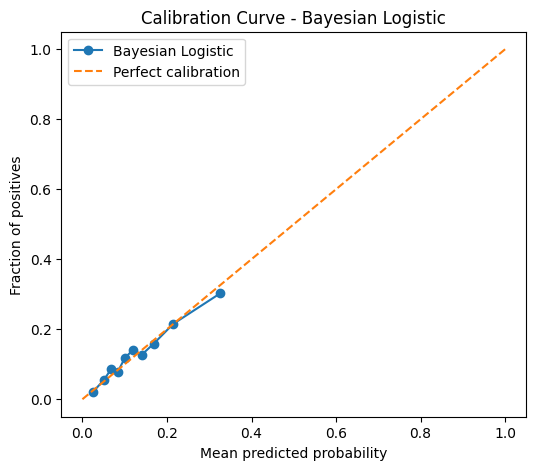

In [ ]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(yte_b, p_bayes, n_bins=10, strategy="quantile")

plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker="o", label="Bayesian Logistic")
plt.plot([0,1], [0,1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration Curve - Bayesian Logistic")
plt.legend()
plt.show()

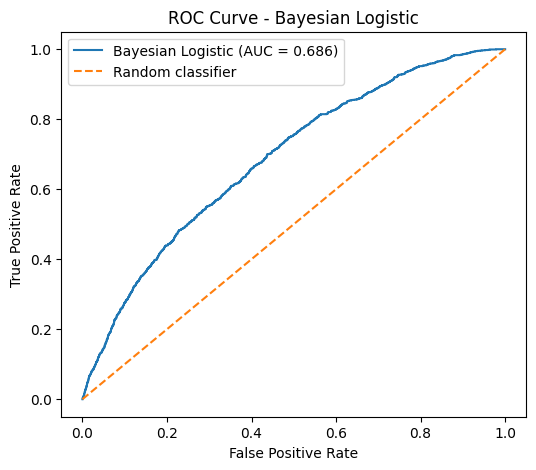

   threshold  precision  recall      f1  specificity     fpr    tp    fp  \
0       0.05     0.1468  0.9647  0.2548       0.1589  0.8411  1258  7314   
1       0.10     0.1830  0.7730  0.2959       0.4824  0.5176  1008  4501   
2       0.15     0.2230  0.5299  0.3139       0.7232  0.2768   691  2407   
3       0.20     0.2691  0.3589  0.3076       0.8538  0.1462   468  1271   
4       0.25     0.3052  0.2301  0.2624       0.9215  0.0785   300   683   
5       0.30     0.3154  0.1304  0.1845       0.9576  0.0424   170   369   
6       0.35     0.3536  0.0759  0.1250       0.9792  0.0208    99   181   
7       0.40     0.3750  0.0437  0.0783       0.9891  0.0109    57    95   
8       0.45     0.3636  0.0215  0.0406       0.9944  0.0056    28    49   
9       0.50     0.3103  0.0069  0.0135       0.9977  0.0023     9    20   

     tn    fn  
0  1382    46  
1  4195   296  
2  6289   613  
3  7425   836  
4  8013  1004  
5  8327  1134  
6  8515  1205  
7  8601  1247  
8  8647  1276  
9  

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_score, recall_score, f1_score,
    confusion_matrix
)

# p_bayes: Bayesian logistic 的预测概率
# yte_b:   test labels (0/1)

# --------------------------------------------------
# A) ROC curve
# --------------------------------------------------
fpr, tpr, roc_thresholds = roc_curve(yte_b, p_bayes)
auc_bayes = roc_auc_score(yte_b, p_bayes)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Bayesian Logistic (AUC = {auc_bayes:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Bayesian Logistic")
plt.legend()
plt.show()

# --------------------------------------------------
# B) Threshold sweep table
# --------------------------------------------------
thresholds = np.arange(0.05, 0.55, 0.05)

rows = []
for th in thresholds:
    yhat = (p_bayes >= th).astype(int)

    tn, fp, fn, tp = confusion_matrix(yte_b, yhat).ravel()

    precision = precision_score(yte_b, yhat, zero_division=0)
    recall = recall_score(yte_b, yhat, zero_division=0)
    f1 = f1_score(yte_b, yhat, zero_division=0)
    specificity = tn / (tn + fp)
    fpr_val = fp / (fp + tn)

    rows.append({
        "threshold": round(th, 2),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
        "specificity": round(specificity, 4),
        "fpr": round(fpr_val, 4),
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn
    })

threshold_df = pd.DataFrame(rows)
print(threshold_df)

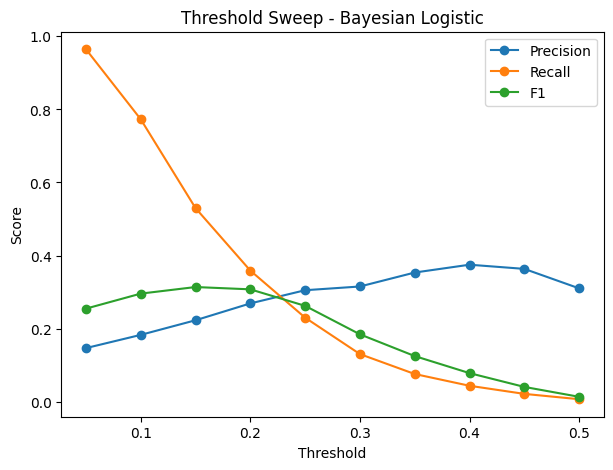

In [ ]:
plt.figure(figsize=(7, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Sweep - Bayesian Logistic")
plt.legend()
plt.show()

In [ ]:
# --------------------------------------------------
# Get feature names after preprocessing
# --------------------------------------------------
feature_names = pre_bayes.get_feature_names_out()
print("Number of transformed features:", len(feature_names))
print(feature_names[:20])

Number of transformed features: 63
['num__loan_amnt' 'num__int_rate' 'num__installment' 'num__annual_inc'
 'num__dti' 'num__delinq_2yrs' 'num__inq_last_6mths' 'num__open_acc'
 'num__pub_rec' 'num__revol_bal' 'num__revol_util' 'num__total_acc'
 'num__acc_now_delinq' 'num__tot_cur_bal' 'num__bc_util' 'num__mort_acc'
 'num__num_actv_bc_tl' 'num__num_actv_rev_tl' 'num__num_bc_sats'
 'num__num_rev_tl_bal_gt_0']


In [ ]:
import arviz as az
import pandas as pd
import numpy as np

# posterior mean of coefficients
beta_mean = trace.posterior["beta"].mean(dim=("chain", "draw")).values

coef_df = pd.DataFrame({
    "feature": feature_names,
    "beta_mean": beta_mean,
    "abs_beta_mean": np.abs(beta_mean)
}).sort_values("abs_beta_mean", ascending=False)

print(coef_df.head(15))

                                  feature  beta_mean  abs_beta_mean
60     cat__disbursement_method_DirectPay  -1.992357       1.992357
55        cat__purpose_infrequent_sklearn  -0.608823       0.608823
54            cat__purpose_small_business   0.591399       0.591399
45  cat__verification_status_Not Verified  -0.462598       0.462598
36                cat__emp_length_6 years  -0.446639       0.446639
51            cat__purpose_major_purchase  -0.335767       0.335767
57             cat__initial_list_status_w  -0.320144       0.320144
1                           num__int_rate   0.307168       0.307168
37                cat__emp_length_7 years  -0.299884       0.299884
28                   cat__term_ 36 months  -0.297761       0.297761
27                    num__total_bc_limit  -0.296823       0.296823
48               cat__purpose_credit_card  -0.293711       0.293711
50          cat__purpose_home_improvement  -0.265423       0.265423
58       cat__application_type_Individual  -0.25

In [ ]:
top_positive = coef_df.sort_values("beta_mean", ascending=False).head(10)
top_negative = coef_df.sort_values("beta_mean", ascending=True).head(10)

print("Top positive coefficients (increase default probability):")
print(top_positive[["feature", "beta_mean"]])

print("\nTop negative coefficients (decrease default probability):")
print(top_negative[["feature", "beta_mean"]])

Top positive coefficients (increase default probability):
                                   feature  beta_mean
54             cat__purpose_small_business   0.591399
1                            num__int_rate   0.307168
4                                 num__dti   0.192970
44  cat__home_ownership_infrequent_sklearn   0.187953
6                      num__inq_last_6mths   0.140328
0                           num__loan_amnt   0.112883
19                num__num_rev_tl_bal_gt_0   0.090047
13                        num__tot_cur_bal   0.081793
16                     num__num_actv_bc_tl   0.067390
18                        num__num_bc_sats   0.058649

Top negative coefficients (decrease default probability):
                                  feature  beta_mean
60     cat__disbursement_method_DirectPay  -1.992357
55        cat__purpose_infrequent_sklearn  -0.608823
45  cat__verification_status_Not Verified  -0.462598
36                cat__emp_length_6 years  -0.446639
51            cat__purpo

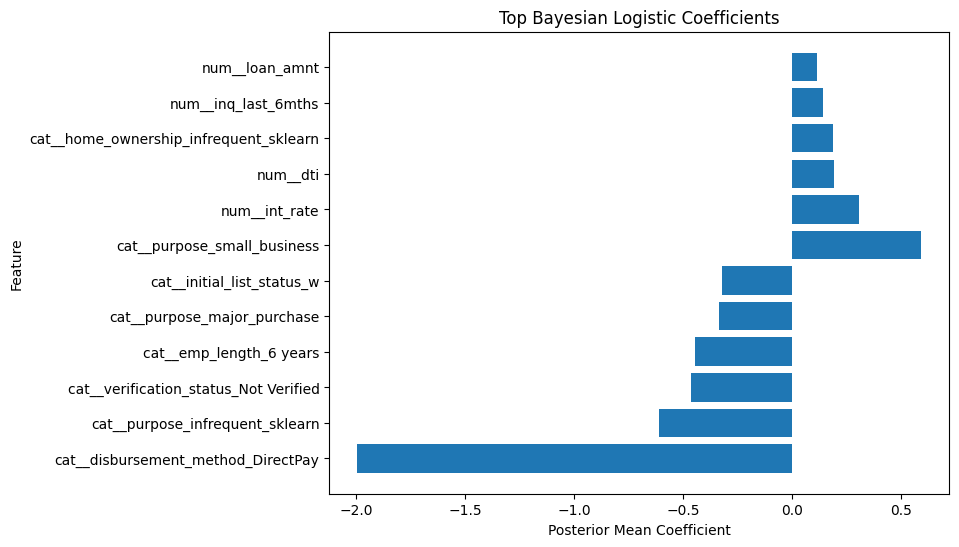

In [ ]:
top_k = 12
plot_df = pd.concat([
    coef_df.sort_values("beta_mean", ascending=True).head(top_k // 2),
    coef_df.sort_values("beta_mean", ascending=False).head(top_k // 2)
])

plt.figure(figsize=(8, 6))
plt.barh(plot_df["feature"], plot_df["beta_mean"])
plt.xlabel("Posterior Mean Coefficient")
plt.ylabel("Feature")
plt.title("Top Bayesian Logistic Coefficients")
plt.show()